# Conversion Rate  : OverSampling managed 🏆🏆

In [8]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, confusion_matrix

import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
#setting Jedha color palette as default
pio.templates["jedha"] = go.layout.Template(
  layout_colorway=["#4B9AC7", "#4BE8E0", "#9DD4F3", "#97FBF6", "#2A7FAF", "#23B1AB", "#0E3449", "#015955"]
)
pio.templates.default = "jedha"
#pio.renderers.default = "svg" # to be replaced by "iframe" if working on JULIE
from IPython.display import display

In [23]:
df = pd.read_csv('conversion_data_train.csv')

In [24]:
# Définition de la cible et des features
target_variable = "converted"
X = df.drop(target_variable, axis=1)
Y = df[target_variable]

# Détection des colonnes numériques et catégorielles
numeric_features = [col for col in X.columns if X[col].dtype in ['int64', 'float64']]
categorical_features = [col for col in X.columns if col not in numeric_features]

# Split train/test
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=0)

# Prétraitement des données
numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(drop="first")
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

# Transformation des données
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

# Encodage des labels
encoder = LabelEncoder()
Y_train = encoder.fit_transform(Y_train)
Y_test = encoder.transform(Y_test)

In [29]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline  # Attention : pas sklearn.pipeline ici
from collections import Counter

# Pipeline de rééchantillonnage
over = SMOTE(sampling_strategy=0.05, random_state=42)
under = RandomUnderSampler(sampling_strategy=0.05, random_state=42)
sampling_pipeline = Pipeline(steps=[('o', over), 
                                    ('u', under)
                                    ]
                                    )

# Appliquer au training set
X_train_resampled, Y_train_resampled = sampling_pipeline.fit_resample(X_train, Y_train)
print("Distribution après rééchantillonnage :", sorted(Counter(Y_train_resampled).items()))


Distribution après rééchantillonnage : [(np.int64(0), 220320), (np.int64(1), 11016)]


In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

In [6]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, f1_score

# Pipeline complet : sampling + classification
pipeline = Pipeline(steps=[
    ('smote', SMOTE(random_state=42)),
    ('under', RandomUnderSampler(random_state=42)),
    ('clf', LogisticRegression(max_iter=1000))
])

# Paramètres à tester
param_grid = {
    'smote__sampling_strategy': [0.01, 0.03, 0.05, 0.07, 0.1],
    'under__sampling_strategy': [0.03, 0.05, 0.07, 0.09, 0.12]
}

# Score personnalisé : F1-score de la classe 1
scorer = make_scorer(f1_score, pos_label=1)

# Grid search
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring=scorer,
    cv=3,
    verbose=2,
    n_jobs=-1
)

# Lancer la recherche
grid_search.fit(X_train, Y_train)

# Afficher les meilleurs résultats
print("Best parameters found:")
print(grid_search.best_params_)

print("\nBest F1 score:")
print(grid_search.best_score_)


Fitting 3 folds for each of 25 candidates, totalling 75 fits


KeyboardInterrupt: 

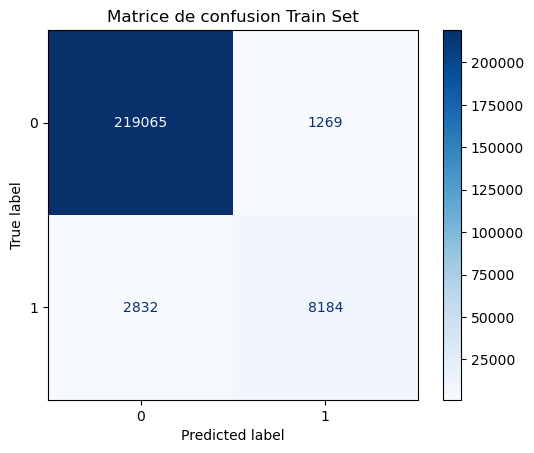

Métriques pour le train set :
              precision    recall  f1-score   support

           0       0.99      0.99      0.99    220334
           1       0.87      0.74      0.80     11016

    accuracy                           0.98    231350
   macro avg       0.93      0.87      0.90    231350
weighted avg       0.98      0.98      0.98    231350



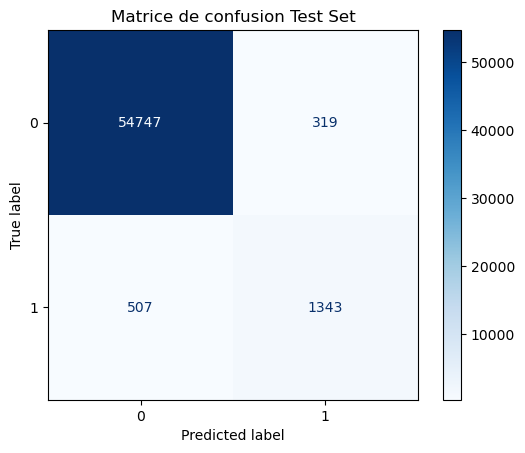

Métriques pour le test set :
              precision    recall  f1-score   support

           0     0.9908    0.9942    0.9925     55066
           1     0.8081    0.7259    0.7648      1850

    accuracy                         0.9855     56916
   macro avg     0.8994    0.8601    0.8787     56916
weighted avg     0.9849    0.9855    0.9851     56916



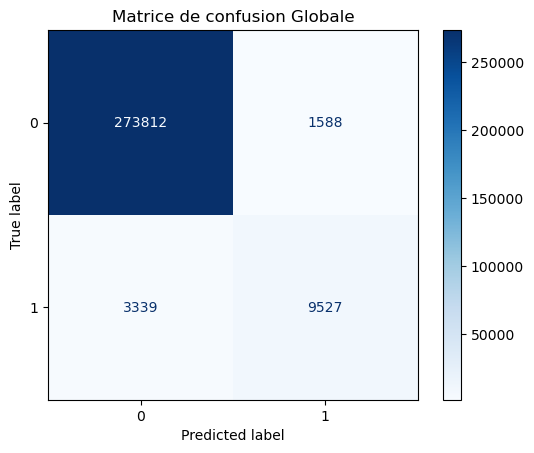

Métriques globales :
              precision    recall  f1-score   support

           0       0.99      0.99      0.99    275400
           1       0.86      0.74      0.79     12866

    accuracy                           0.98    288266
   macro avg       0.92      0.87      0.89    288266
weighted avg       0.98      0.98      0.98    288266



In [28]:
# Construire et entraîner le modèle de régression logistique avec les données rééchantillonnées
logistic_model = LogisticRegression()
logistic_model.fit(X_train_resampled, Y_train_resampled)

# Prédictions
Y_train_pred = logistic_model.predict(X_train_resampled)
Y_test_pred = logistic_model.predict(X_test)

# Matrice de confusion pour le train set
cm_train = confusion_matrix(Y_train_resampled, Y_train_pred)
disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train)
disp_train.plot(cmap='Blues')
plt.title("Matrice de confusion Train Set")
plt.show()

# Métriques pour le train set
print("Métriques pour le train set :")
print(classification_report(Y_train_resampled, Y_train_pred))

# Matrice de confusion pour le test set
cm_test = confusion_matrix(Y_test, Y_test_pred)
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test)
disp_test.plot(cmap='Blues')
plt.title("Matrice de confusion Test Set")
plt.show()

# Métriques pour le test set
print("Métriques pour le test set :")
print(classification_report(Y_test, Y_test_pred, digits=4))

# Matrice de confusion globale (train + test)
Y_global = np.concatenate((Y_train_resampled, Y_test))
Y_global_pred = np.concatenate((Y_train_pred, Y_test_pred))
cm_global = confusion_matrix(Y_global, Y_global_pred)
disp_global = ConfusionMatrixDisplay(confusion_matrix=cm_global)
disp_global.plot(cmap='Blues')
plt.title("Matrice de confusion Globale")
plt.show()

# Métriques globales
print("Métriques globales :")
print(classification_report(Y_global, Y_global_pred))


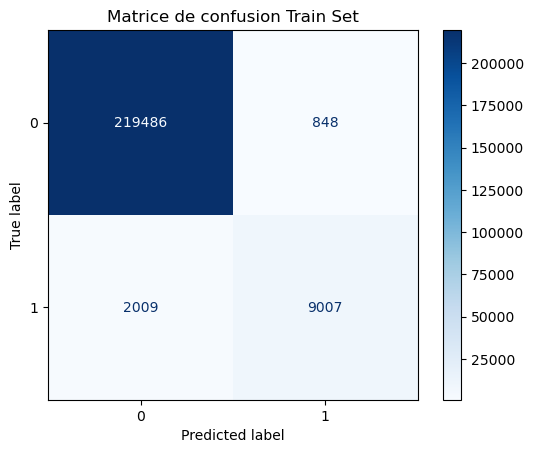

Métriques pour le train set :
              precision    recall  f1-score   support

           0       0.99      1.00      0.99    220334
           1       0.91      0.82      0.86     11016

    accuracy                           0.99    231350
   macro avg       0.95      0.91      0.93    231350
weighted avg       0.99      0.99      0.99    231350



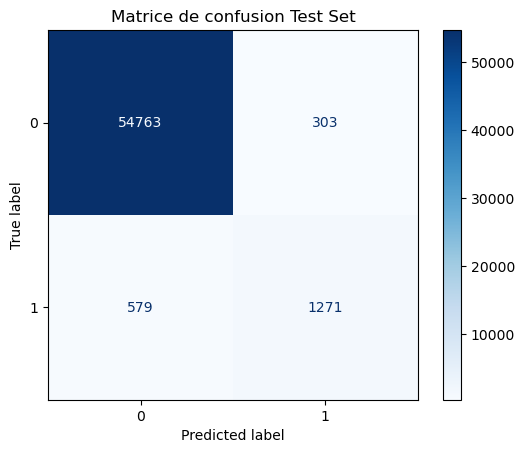

Métriques pour le test set :
              precision    recall  f1-score   support

           0     0.9895    0.9945    0.9920     55066
           1     0.8075    0.6870    0.7424      1850

    accuracy                         0.9845     56916
   macro avg     0.8985    0.8408    0.8672     56916
weighted avg     0.9836    0.9845    0.9839     56916



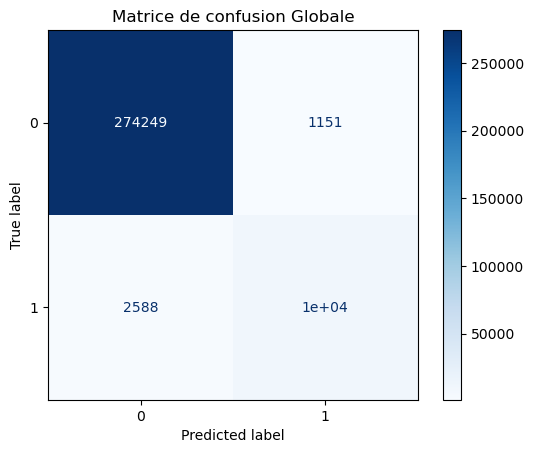

Métriques globales :
              precision    recall  f1-score   support

           0       0.99      1.00      0.99    275400
           1       0.90      0.80      0.85     12866

    accuracy                           0.99    288266
   macro avg       0.94      0.90      0.92    288266
weighted avg       0.99      0.99      0.99    288266



In [82]:
# Construire et entraîner le modèle de Random Forest avec les données rééchantillonnées
from sklearn.ensemble import RandomForestClassifier

random_forest_model = RandomForestClassifier(n_estimators=100, random_state=42)
random_forest_model.fit(X_train_resampled, Y_train_resampled)

# Prédictions
Y_train_pred = random_forest_model.predict(X_train_resampled)
Y_test_pred = random_forest_model.predict(X_test)

# Matrice de confusion pour le train set
cm_train = confusion_matrix(Y_train_resampled, Y_train_pred)
disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train)
disp_train.plot(cmap='Blues')
plt.title("Matrice de confusion Train Set")
plt.show()

# Métriques pour le train set
print("Métriques pour le train set :")
print(classification_report(Y_train_resampled, Y_train_pred))

# Matrice de confusion pour le test set
cm_test = confusion_matrix(Y_test, Y_test_pred)
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test)
disp_test.plot(cmap='Blues')
plt.title("Matrice de confusion Test Set")
plt.show()

# Métriques pour le test set
print("Métriques pour le test set :")
print(classification_report(Y_test, Y_test_pred, digits=4))

# Matrice de confusion globale (train + test)
Y_global = np.concatenate((Y_train_resampled, Y_test))
Y_global_pred = np.concatenate((Y_train_pred, Y_test_pred))
cm_global = confusion_matrix(Y_global, Y_global_pred)
disp_global = ConfusionMatrixDisplay(confusion_matrix=cm_global)
disp_global.plot(cmap='Blues')
plt.title("Matrice de confusion Globale")
plt.show()

# Métriques globales
print("Métriques globales :")
print(classification_report(Y_global, Y_global_pred))


In [12]:
print("f1-score on train set : ", f1_score(Y_train_resampled, Y_train_pred))
print("f1-score on test set : ", f1_score(Y_test, Y_test_pred))


f1-score on train set :  0.8634908500167232
f1-score on test set :  0.7439165701042874


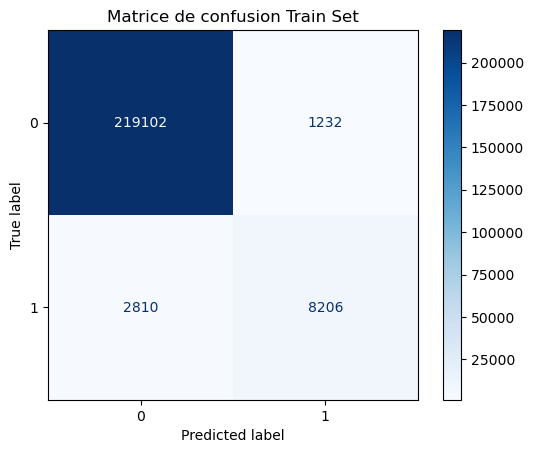

Métriques pour le train set :
              precision    recall  f1-score   support

           0       0.99      0.99      0.99    220334
           1       0.87      0.74      0.80     11016

    accuracy                           0.98    231350
   macro avg       0.93      0.87      0.90    231350
weighted avg       0.98      0.98      0.98    231350



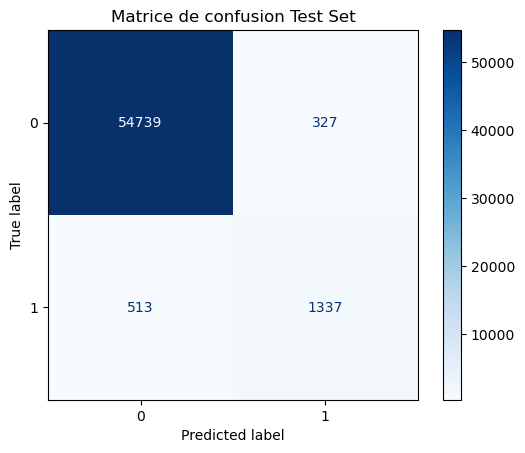

Métriques pour le test set :
              precision    recall  f1-score   support

           0     0.9907    0.9941    0.9924     55066
           1     0.8035    0.7227    0.7610      1850

    accuracy                         0.9852     56916
   macro avg     0.8971    0.8584    0.8767     56916
weighted avg     0.9846    0.9852    0.9849     56916



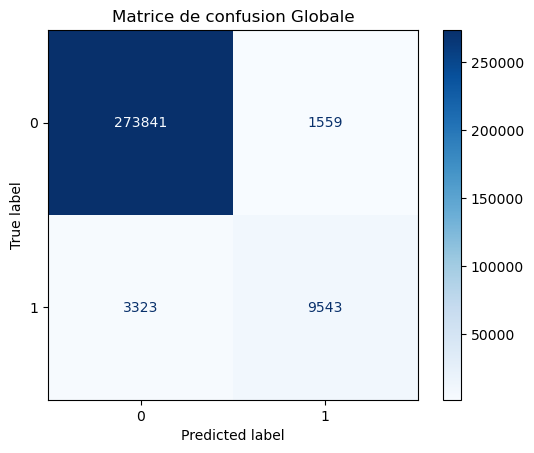

Métriques globales :
              precision    recall  f1-score   support

           0       0.99      0.99      0.99    275400
           1       0.86      0.74      0.80     12866

    accuracy                           0.98    288266
   macro avg       0.92      0.87      0.89    288266
weighted avg       0.98      0.98      0.98    288266



In [84]:
# Construire et entraîner le modèle XGBoost avec les données rééchantillonnées
import xgboost as xgb

xgb_model = xgb.XGBClassifier(
    objective='binary:logistic',
    max_depth=5,
    learning_rate=0.1,
    n_estimators=100,
    random_state=42
)
xgb_model.fit(X_train_resampled, Y_train_resampled)

# Prédictions
Y_train_pred = xgb_model.predict(X_train_resampled)
Y_test_pred = xgb_model.predict(X_test)

# Matrice de confusion pour le train set
cm_train = confusion_matrix(Y_train_resampled, Y_train_pred)
disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train)
disp_train.plot(cmap='Blues')
plt.title("Matrice de confusion Train Set")
plt.show()

# Métriques pour le train set
print("Métriques pour le train set :")
print(classification_report(Y_train_resampled, Y_train_pred))

# Matrice de confusion pour le test set
cm_test = confusion_matrix(Y_test, Y_test_pred)
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test)
disp_test.plot(cmap='Blues')
plt.title("Matrice de confusion Test Set")
plt.show()

# Métriques pour le test set
print("Métriques pour le test set :")
print(classification_report(Y_test, Y_test_pred, digits=4))

# Matrice de confusion globale (train + test)
Y_global = np.concatenate((Y_train_resampled, Y_test))
Y_global_pred = np.concatenate((Y_train_pred, Y_test_pred))
cm_global = confusion_matrix(Y_global, Y_global_pred)
disp_global = ConfusionMatrixDisplay(confusion_matrix=cm_global)
disp_global.plot(cmap='Blues')
plt.title("Matrice de confusion Globale")
plt.show()

# Métriques globales
print("Métriques globales :")
print(classification_report(Y_global, Y_global_pred))


In [99]:
print("f1-score on train set : ", f1_score(Y_train_resampled, Y_train_pred))
print("f1-score on test set : ", f1_score(Y_test, Y_test_pred))

f1-score on train set :  0.8026000684228533
f1-score on test set :  0.7609561752988048


In [ ]:
from sklearn.ensemble import (
    BaggingClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    VotingClassifier,
    StackingClassifier,
)
from xgboost import XGBClassifier

# import base estimators
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
)

## Performance assessment

In [15]:
print("f1-score on train set : ", f1_score(Y_train_resampled, Y_train_pred))
print("f1-score on test set : ", f1_score(Y_test, Y_test_pred))

f1-score on train set :  0.8026000684228533
f1-score on test set :  0.7609561752988048


[I 2025-08-04 22:08:42,624] A new study created in memory with name: no-name-658fb12a-db46-4d5a-95f1-b0b8e9feea09



🎯 Début de l'optimisation Optuna (paramètres étendus)...


Optuna Trials: 100%|██████████| 50/50 [01:31<00:00,  1.84s/it]


✅ Optuna terminé!
Meilleurs paramètres Optuna: {'n_estimators': 380, 'max_depth': 12, 'learning_rate': 0.0803221818955271, 'subsample': 0.6330979498651184, 'colsample_bytree': 0.8517398095924904, 'gamma': 3.248732462730011, 'reg_alpha': 3.9549252089553018, 'reg_lambda': 1.2171038681022963, 'min_child_weight': 8}

📊 Évaluation du modèle final

🔹 Train Set
Accuracy: 0.9823
F1 macro: 0.8955
F1 weighted: 0.9816
              precision    recall  f1-score   support

           0     0.9874    0.9940    0.9907    220320
           1     0.8621    0.7468    0.8003     11016

    accuracy                         0.9823    231336
   macro avg     0.9248    0.8704    0.8955    231336
weighted avg     0.9815    0.9823    0.9816    231336



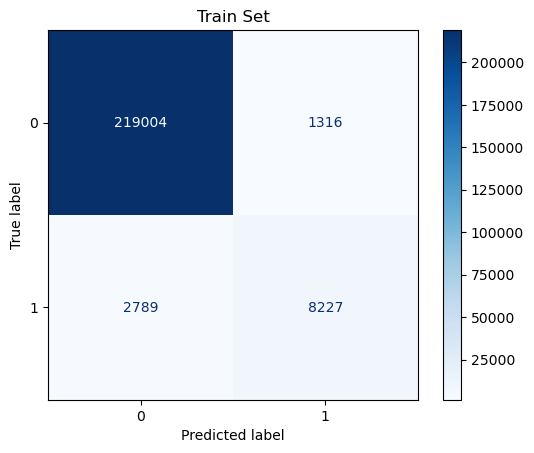


🔹 Test Set
Accuracy: 0.9855
F1 macro: 0.8791
F1 weighted: 0.9851
              precision    recall  f1-score   support

           0     0.9910    0.9940    0.9925     55066
           1     0.8034    0.7314    0.7657      1850

    accuracy                         0.9855     56916
   macro avg     0.8972    0.8627    0.8791     56916
weighted avg     0.9849    0.9855    0.9851     56916



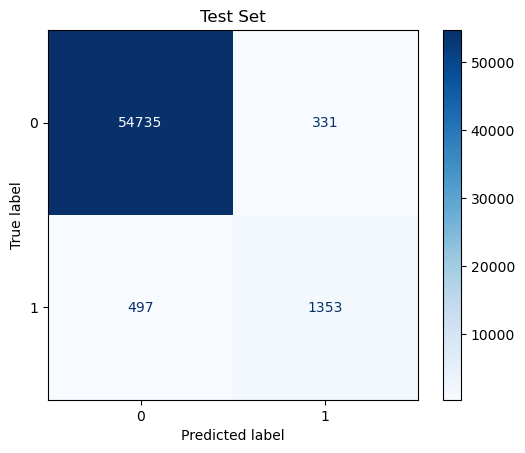


🔹 Global Set
Accuracy: 0.9829
F1 macro: 0.8932
F1 weighted: 0.9823
              precision    recall  f1-score   support

           0     0.9881    0.9940    0.9911    275386
           1     0.8533    0.7446    0.7953     12866

    accuracy                         0.9829    288252
   macro avg     0.9207    0.8693    0.8932    288252
weighted avg     0.9821    0.9829    0.9823    288252



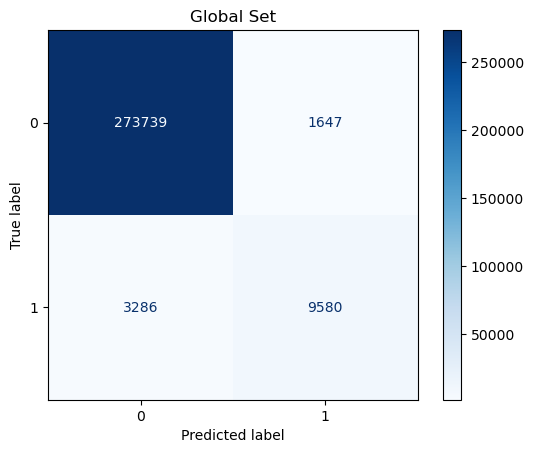


🎯 Résumé F1:
F1 Score Train Set : 0.8955
F1 Score Test Set  : 0.8791


In [110]:
import xgboost as xgb
import optuna
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score, classification_report
from sklearn.model_selection import GridSearchCV, train_test_split
from tqdm import tqdm
from xgboost.callback import EarlyStopping

# Étape 1 : GridSearchCV élargi
xgb_model = xgb.XGBClassifier(
    eval_metric="logloss",
    random_state=42,
    #use_label_encoder=False
)

# Étape 2 : Optuna avec espace élargi
def objective(trial):
    param = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500, step=20),
        "max_depth": trial.suggest_int("max_depth", 2, 12),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "gamma": trial.suggest_float("gamma", 0, 5),
        "reg_alpha": trial.suggest_float("reg_alpha", 0, 5),
        "reg_lambda": trial.suggest_float("reg_lambda", 0, 5),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 20),
        "eval_metric": "logloss",
        "random_state": 42,
    }

    model = xgb.XGBClassifier(**param)
    
    model.fit(
    X_train_resampled,
    Y_train_resampled,
    eval_set=[(X_test, Y_test)],
    verbose=False,
)


    preds = model.predict(X_test)
    return f1_score(Y_test, preds, average="macro")

print("\n🎯 Début de l'optimisation Optuna (paramètres étendus)...")
study = optuna.create_study(direction="maximize")
with tqdm(total=50, desc="Optuna Trials") as pbar:
    def tqdm_callback(study, trial):
        pbar.update(1)
    study.optimize(objective, n_trials=50, callbacks=[tqdm_callback])

print("✅ Optuna terminé!")
print("Meilleurs paramètres Optuna:", study.best_params)

# Étape 3 : Modèle final
final_params = dict(study.best_params)
final_params.update({"eval_metric": "logloss", "random_state": 42})
final_model = xgb.XGBClassifier(**final_params)
final_model.fit(X_train_resampled, Y_train_resampled)

# Étape 4 : Évaluation
print("\n📊 Évaluation du modèle final")
y_train_pred = final_model.predict(X_train_resampled)
y_test_pred = final_model.predict(X_test)
y_global_true = np.concatenate([Y_train_resampled, Y_test])
y_global_pred = np.concatenate([y_train_pred, y_test_pred])

def display_metrics(y_true, y_pred, title):
    accuracy = np.mean(y_true == y_pred)
    f1_macro = f1_score(y_true, y_pred, average="macro")
    f1_weighted = f1_score(y_true, y_pred, average="weighted")

    print(f"\n🔹 {title}")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1 macro: {f1_macro:.4f}")
    print(f"F1 weighted: {f1_weighted:.4f}")
    print(classification_report(y_true, y_pred, digits=4))

    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap="Blues")
    plt.title(title)
    plt.show()

# Résultats
display_metrics(Y_train_resampled, y_train_pred, "Train Set")
display_metrics(Y_test, y_test_pred, "Test Set")
display_metrics(y_global_true, y_global_pred, "Global Set")

# Résumé F1
print("\n🎯 Résumé F1:")
print(f"F1 Score Train Set : {f1_score(Y_train_resampled, y_train_pred, average='macro'):.4f}")
print(f"F1 Score Test Set  : {f1_score(Y_test, y_test_pred, average='macro'):.4f}")


In [115]:
import plotly.express as px
import pandas as pd

# Supposons que 'feature_names' et 'importance' soient déjà définis

# 1. Obtenir les importances depuis le booster (par gain)
importance = final_model.get_booster().get_score(importance_type='gain')

# 2. Obtenir les noms des features transformées
# Assure-toi que 'preprocessor' est fitted
feature_names = preprocessor.get_feature_names_out()


feat_imp = []
for feat_id, imp in importance.items():
    idx = int(feat_id[1:])  # f0 -> 0
    if idx < len(feature_names):
        feat_imp.append((feature_names[idx], imp))

# Tri décroissant
feat_imp_sorted = sorted(feat_imp, key=lambda x: x[1], reverse=True)
df_feat_imp = pd.DataFrame(feat_imp_sorted, columns=["Feature", "Importance"])

# Création du graphique avec Plotly Express
fig = px.bar(
    df_feat_imp,
    x="Importance",
    y="Feature",
    orientation="h",
    color="Importance",
    color_continuous_scale=["#b1b94d", "#388730"],  # Palette de couleurs verte
    title="🎯 Importance des Features (Gain - XGBoost)",
    labels={"Importance": "Gain", "Feature": "Variable"},
)

fig.update_layout(
    yaxis=dict(categoryorder="total ascending"),
    font=dict(size=12),
    height=600,
    margin=dict(l=200, r=40, t=50, b=40),
    coloraxis_showscale=False,  # Cache la légende de couleur si vous le souhaitez
)

fig.show()


In [116]:
# Supposons que 'feature_names' et 'importance' soient déjà définis
feat_imp = []
for feat_id, imp in importance.items():
    idx = int(feat_id[1:])  # f0 -> 0
    if idx < len(feature_names):
        feat_imp.append((feature_names[idx], imp))

# Tri décroissant
feat_imp_sorted = sorted(feat_imp, key=lambda x: x[1], reverse=True)
df_feat_imp = pd.DataFrame(feat_imp_sorted, columns=["Feature", "Importance"])

# Création du graphique avec Plotly Express
fig = px.bar(
    df_feat_imp,
    x="Importance",
    y="Feature",
    orientation="h",
    color="Importance",
    color_continuous_scale=["#b1b94d", "#388730"],  # Palette de couleurs verte
    title="🎯 Importance des Features (Gain - XGBoost)",
    labels={"Importance": "Gain", "Feature": "Variable"},
    text="Importance",  # Ajoute les valeurs d'importance sur les barres
)

fig.update_layout(
    yaxis=dict(categoryorder="total ascending"),
    font=dict(size=12),
    height=600,
    margin=dict(l=200, r=40, t=50, b=40),
    coloraxis_showscale=False,  # Cache la légende de couleur si vous le souhaitez
)

# Ajuster l'affichage du texte sur les barres
fig.update_traces(texttemplate='%{text:.4f}', textposition='outside')

fig.show()

[I 2025-08-05 10:33:46,483] A new study created in memory with name: no-name-20cdb601-a182-4456-a6c1-f6e91a6d78d5



🎯 Début de l'optimisation Optuna (LightGBM)...


Optuna Trials:   0%|          | 0/50 [00:00<?, ?it/s]/Users/eric/Desktop/JEDHA/SMOLAGENT/.conda/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
[I 2025-08-05 10:33:48,927] Trial 0 finished with value: 0.8753781458408294 and parameters: {'n_estimators': 280, 'max_depth': 11, 'learning_rate': 0.1587369589231293, 'subsample': 0.8501591272535409, 'colsample_bytree': 0.8746202142567434, 'reg_alpha': 3.088271683621271, 'reg_lambda': 0.8226102849854239, 'min_child_weight': 7}. Best is trial 0 with value: 0.8753781458408294.
Optuna Trials:   2%|▏         | 1/50 [00:02<01:59,  2.44s/it]/Users/eric/Desktop/JEDHA/SMOLAGENT/.conda/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
[I 2025-08-05 10:33:51,412] Trial 1 finished with value: 0.8758

✅ Optuna terminé!
Meilleurs paramètres Optuna: {'n_estimators': 320, 'max_depth': 3, 'learning_rate': 0.08149171455286376, 'subsample': 0.7250164101204051, 'colsample_bytree': 0.7889146470076513, 'reg_alpha': 2.9698779311699846, 'reg_lambda': 1.698129282164183, 'min_child_weight': 6}

📊 Évaluation du modèle final


/Users/eric/Desktop/JEDHA/SMOLAGENT/.conda/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/eric/Desktop/JEDHA/SMOLAGENT/.conda/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



🔹 Train Set
Accuracy: 0.9828
F1 macro: 0.8984
F1 weighted: 0.9822
              precision    recall  f1-score   support

           0     0.9875    0.9946    0.9910    220320
           1     0.8730    0.7481    0.8057     11016

    accuracy                         0.9828    231336
   macro avg     0.9302    0.8713    0.8984    231336
weighted avg     0.9820    0.9828    0.9822    231336



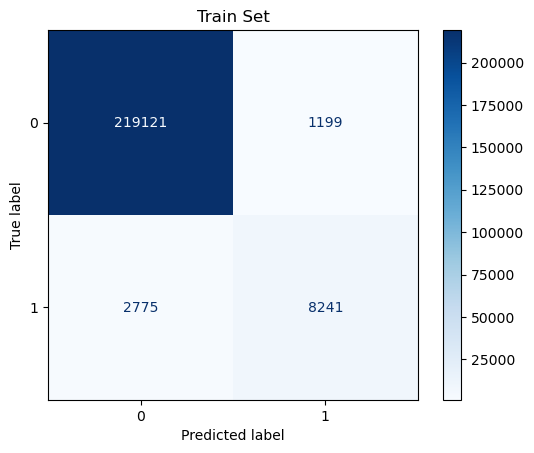


🔹 Test Set
Accuracy: 0.9856
F1 macro: 0.8792
F1 weighted: 0.9852
              precision    recall  f1-score   support

           0     0.9907    0.9945    0.9926     55066
           1     0.8151    0.7222    0.7658      1850

    accuracy                         0.9856     56916
   macro avg     0.9029    0.8583    0.8792     56916
weighted avg     0.9850    0.9856    0.9852     56916



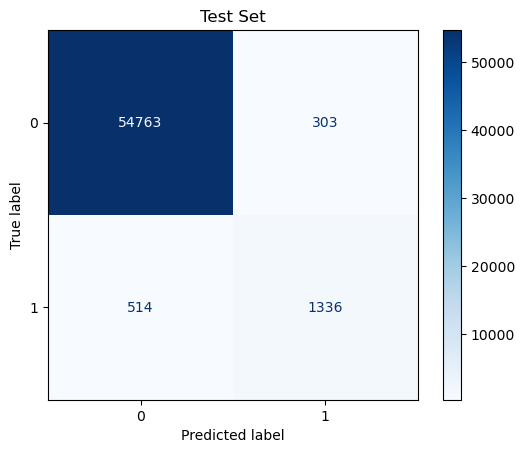


🔹 Global Set
Accuracy: 0.9834
F1 macro: 0.8956
F1 weighted: 0.9828
              precision    recall  f1-score   support

           0     0.9881    0.9945    0.9913    275386
           1     0.8644    0.7444    0.7999     12866

    accuracy                         0.9834    288252
   macro avg     0.9263    0.8695    0.8956    288252
weighted avg     0.9826    0.9834    0.9828    288252



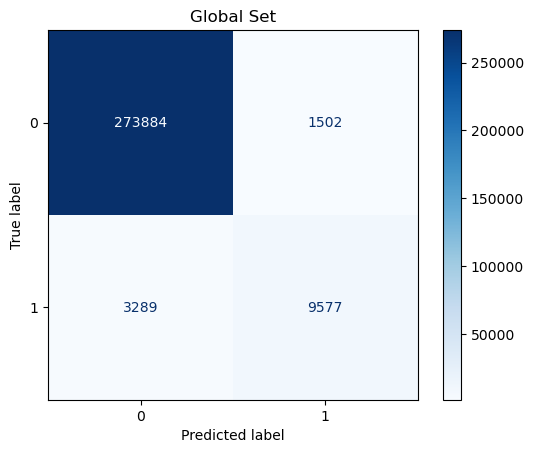


🎯 Résumé F1:
F1 Score Train Set : 0.8984
F1 Score Test Set  : 0.8792


In [32]:
import lightgbm as lgb
import optuna
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score, classification_report
from sklearn.model_selection import train_test_split
from tqdm import tqdm

# Étape 1 : Définition du modèle de base (pas encore utilisé ici)
lgb_model = lgb.LGBMClassifier(random_state=42)

# Étape 2 : Optuna avec espace de recherche étendu
def objective(trial):
    param = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500, step=20),
        "max_depth": trial.suggest_int("max_depth", 2, 12),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 5.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.0, 5.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 20),
        "random_state": 42,
        "boosting_type": "gbdt",
        "objective": "binary" if len(np.unique(Y_train_resampled)) == 2 else "multiclass",
        "metric": "multi_logloss" if len(np.unique(Y_train_resampled)) > 2 else "binary_logloss",
        "verbosity": -1
    }

    if len(np.unique(Y_train_resampled)) > 2:
        param["num_class"] = len(np.unique(Y_train_resampled))

    model = lgb.LGBMClassifier(**param)

    model.fit(
        X_train_resampled,
        Y_train_resampled,
        eval_set=[(X_test, Y_test)],
        eval_metric="logloss",
        #early_stopping_rounds=10,
        #verbose=False,
    )

    preds = model.predict(X_test)
    return f1_score(Y_test, preds, average="macro")


print("\n🎯 Début de l'optimisation Optuna (LightGBM)...")
study = optuna.create_study(direction="maximize")
with tqdm(total=50, desc="Optuna Trials") as pbar:
    def tqdm_callback(study, trial):
        pbar.update(1)
    study.optimize(objective, n_trials=50, callbacks=[tqdm_callback])

print("✅ Optuna terminé!")
print("Meilleurs paramètres Optuna:", study.best_params)

# Étape 3 : Modèle final avec les meilleurs hyperparamètres
final_params = dict(study.best_params)
final_params.update({
    "random_state": 42,
    "boosting_type": "gbdt",
    "objective": "binary" if len(np.unique(Y_train_resampled)) == 2 else "multiclass",
    "metric": "multi_logloss" if len(np.unique(Y_train_resampled)) > 2 else "binary_logloss",
    "verbosity": -1
})
if len(np.unique(Y_train_resampled)) > 2:
    final_params["num_class"] = len(np.unique(Y_train_resampled))

final_model = lgb.LGBMClassifier(**final_params)
final_model.fit(X_train_resampled, Y_train_resampled)

# Étape 4 : Évaluation
print("\n📊 Évaluation du modèle final")
y_train_pred = final_model.predict(X_train_resampled)
y_test_pred = final_model.predict(X_test)
y_global_true = np.concatenate([Y_train_resampled, Y_test])
y_global_pred = np.concatenate([y_train_pred, y_test_pred])

def display_metrics(y_true, y_pred, title):
    accuracy = np.mean(y_true == y_pred)
    f1_macro = f1_score(y_true, y_pred, average="macro")
    f1_weighted = f1_score(y_true, y_pred, average="weighted")

    print(f"\n🔹 {title}")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1 macro: {f1_macro:.4f}")
    print(f"F1 weighted: {f1_weighted:.4f}")
    print(classification_report(y_true, y_pred, digits=4))

    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap="Blues")
    plt.title(title)
    plt.show()

# Résultats
display_metrics(Y_train_resampled, y_train_pred, "Train Set")
display_metrics(Y_test, y_test_pred, "Test Set")
display_metrics(y_global_true, y_global_pred, "Global Set")

# Résumé F1
print("\n🎯 Résumé F1:")
print(f"F1 Score Train Set : {f1_score(Y_train_resampled, y_train_pred, average='macro'):.4f}")
print(f"F1 Score Test Set  : {f1_score(Y_test, y_test_pred, average='macro'):.4f}")


In [33]:
import joblib

# Sauvegarde du modèle, du préprocesseur, du label encoder
joblib.dump(final_model, "lightgbm_model.pkl")
joblib.dump(preprocessor, "preprocessor.pkl")
joblib.dump(encoder, "label_encoder.pkl")
print("✅ Modèle, préprocesseur et encoder sauvegardés.")


✅ Modèle, préprocesseur et encoder sauvegardés.


In [37]:
import joblib
joblib.dump(X_train_resampled, "X_train_resampled.pkl")
joblib.dump(Y_train_resampled, "Y_train_resampled.pkl")
joblib.dump(X_test, "X_test.pkl")
joblib.dump(Y_test, "Y_test.pkl")


['Y_test.pkl']

In [35]:
import pandas as pd
import numpy as np
import joblib
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 📥 Charger les objets sauvegardés
model = joblib.load("lightgbm_model.pkl")
preprocessor = joblib.load("preprocessor.pkl")

# 📂 Charger les données
df = pd.read_csv("conversion_data_test.csv")

# 🎯 Vérifie si la colonne 'converted' existe
has_target = "converted" in df.columns

# 🎛️ Séparer les features et la target si elle existe
if has_target:
    X = df.drop("converted", axis=1)
    Y_true = df["converted"]
else:
    X = df
    Y_true = None

# 🛠️ Appliquer le même préprocessing
X_transformed = preprocessor.transform(X)

# 🔮 Prédictions
y_pred = model.predict(X_transformed)

# 📝 Si la target est présente → évaluation
if has_target:
    from sklearn.metrics import accuracy_score, f1_score

    def display_metrics(y_true, y_pred, title):
        acc = accuracy_score(y_true, y_pred)
        f1_macro = f1_score(y_true, y_pred, average='macro')
        f1_weighted = f1_score(y_true, y_pred, average='weighted')

        print(f"\n🔹 {title}")
        print(f"Accuracy       : {acc:.4f}")
        print(f"F1 macro       : {f1_macro:.4f}")
        print(f"F1 weighted    : {f1_weighted:.4f}")
        print(classification_report(y_true, y_pred, digits=4))

        cm = confusion_matrix(y_true, y_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm)
        disp.plot(cmap="Blues")
        plt.title(title)
        plt.show()

    display_metrics(Y_true, y_pred, "📊 Evaluation sur le test externe")

else:
    # 💾 Sauvegarde les prédictions dans un CSV
    output = df.copy()
    output["converted_pred"] = y_pred
    output.to_csv("conversion_predictions.csv", index=False)
    print("✅ Prédictions sauvegardées dans 'conversion_predictions.csv'")


/Users/eric/Desktop/JEDHA/SMOLAGENT/.conda/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


✅ Prédictions sauvegardées dans 'conversion_predictions.csv'


/Users/eric/Desktop/JEDHA/SMOLAGENT/.conda/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


✅ Prédictions sauvegardées dans conversion_predictions.csv


/Users/eric/Desktop/JEDHA/SMOLAGENT/.conda/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



🔹 🎯 Train Set
Accuracy       : 0.9828
F1 macro       : 0.8984
F1 weighted    : 0.9822
              precision    recall  f1-score   support

           0     0.9875    0.9946    0.9910    220320
           1     0.8730    0.7481    0.8057     11016

    accuracy                         0.9828    231336
   macro avg     0.9302    0.8713    0.8984    231336
weighted avg     0.9820    0.9828    0.9822    231336



/Users/eric/Desktop/JEDHA/SMOLAGENT/.conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


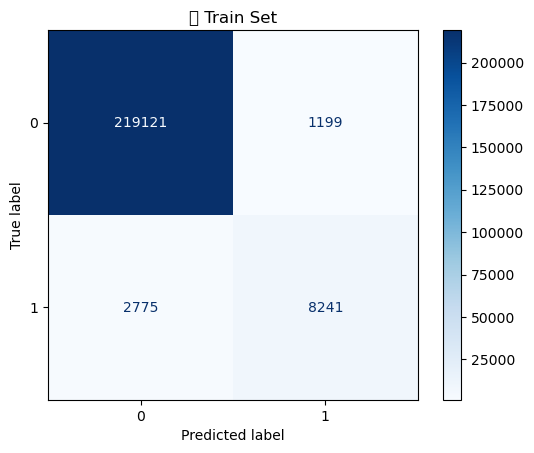

In [40]:
import pandas as pd
import joblib
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# 📥 Charger le modèle, le préprocesseur et l'encoder
model = joblib.load("lightgbm_model.pkl")
preprocessor = joblib.load("preprocessor.pkl")
encoder = joblib.load("label_encoder.pkl")

# 📥 Charger le jeu d'entraînement (pour évaluation)
X_train_resampled = joblib.load("X_train_resampled.pkl")
Y_train_resampled = joblib.load("Y_train_resampled.pkl")

# 📥 Charger le fichier test sans target
df_test = pd.read_csv("conversion_data_test.csv")

# 🎯 Appliquer le préprocessing sur les features
X_test_transformed = preprocessor.transform(df_test)

# 🔮 Prédire la target
y_test_pred_encoded = model.predict(X_test_transformed)
y_test_pred = encoder.inverse_transform(y_test_pred_encoded)

# 💾 Ajouter les prédictions au DataFrame
df_test["converted_predicted"] = y_test_pred

# 💾 Sauvegarder les prédictions
df_test.to_csv("conversion_predictions.csv", index=False)
print("✅ Prédictions sauvegardées dans conversion_predictions.csv")

# 📊 Évaluation uniquement sur le train set (le test set n’a pas de ground truth)
y_train_pred = model.predict(X_train_resampled)

def display_metrics(y_true, y_pred, title):
    acc = accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average='macro')
    f1_weighted = f1_score(y_true, y_pred, average='weighted')

    print(f"\n🔹 {title}")
    print(f"Accuracy       : {acc:.4f}")
    print(f"F1 macro       : {f1_macro:.4f}")
    print(f"F1 weighted    : {f1_weighted:.4f}")
    print(classification_report(y_true, y_pred, digits=4))

    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap="Blues")
    plt.title(title)
    plt.show()

# ✅ Afficher les performances sur le train set
display_metrics(Y_train_resampled, y_train_pred, "🎯 Train Set")



🔍 Top 20 features importantes :
               Feature  Importance
2  total_pages_visited         779
0                  age         655
1             new_user         132
5           country_US         109
3      country_Germany         100
4           country_UK          96
7           source_Seo          57
6        source_Direct          47


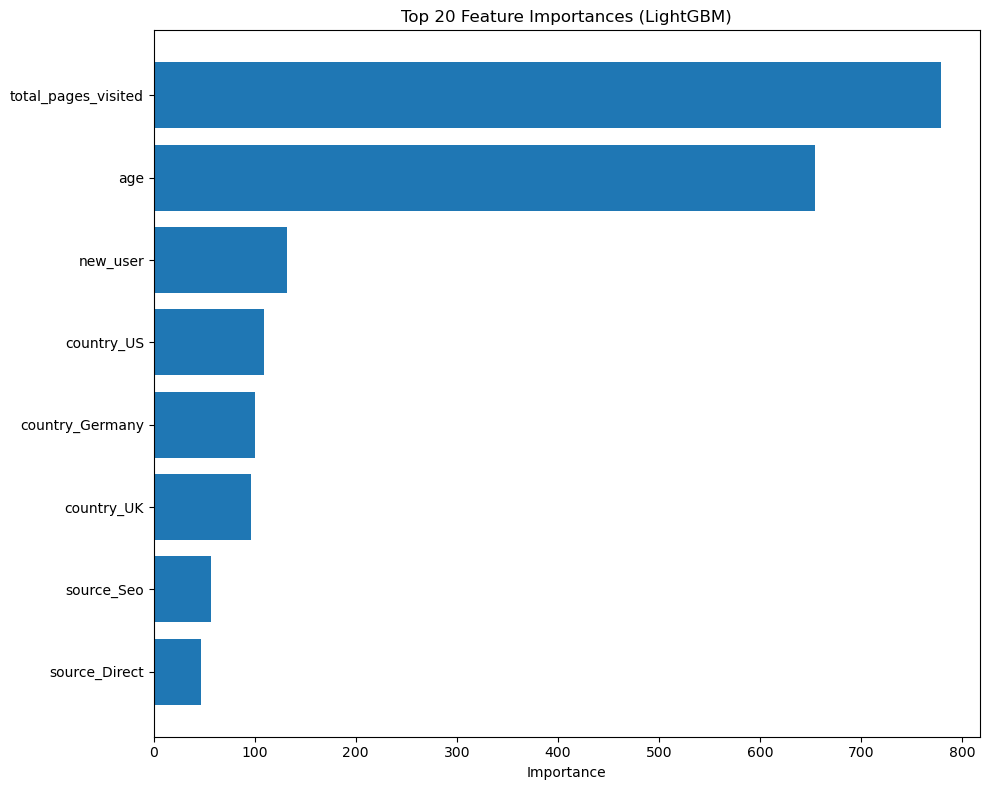

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Charger le modèle et le preprocessor
import joblib
model = joblib.load("lightgbm_model.pkl")
preprocessor = joblib.load("preprocessor.pkl")

# Récupérer les noms des colonnes transformées
# 1. Colonnes numériques
num_features = preprocessor.transformers_[0][2]

# 2. Colonnes catégorielles
ohe = preprocessor.transformers_[1][1]  # OneHotEncoder
cat_features = preprocessor.transformers_[1][2]

# Obtenir les noms après OHE
ohe_feature_names = ohe.get_feature_names_out(cat_features)

# Combiner tous les noms finaux
feature_names = np.concatenate([num_features, ohe_feature_names])

# Récupérer l’importance des features
importances = model.feature_importances_

# Associer nom + importance
feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

# Afficher les top features
print("\n🔍 Top 20 features importantes :")
print(feature_importance_df.head(20))

# Optionnel : graphique
plt.figure(figsize=(10, 8))
plt.barh(feature_importance_df.head(20)["Feature"][::-1], feature_importance_df.head(20)["Importance"][::-1])
plt.xlabel("Importance")
plt.title("Top 20 Feature Importances (LightGBM)")
plt.tight_layout()
plt.show()
